In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


In [3]:

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

plt.rcParams.update({

    # Fonte (mais leve visualmente)
    'font.family': 'DejaVu Sans',
    
    # Cor geral do texto (cinza suave ao invés de preto)
    'text.color': '#333333',
    'axes.labelcolor': '#4a4a4a',
    'xtick.color': '#6a6a6a',
    'ytick.color': '#6a6a6a',
    
    # Título geral (suave, não gigante)
    'figure.titlesize': 18,
    'figure.titleweight': 'medium',
    
    # Título dos subplots
    'axes.titlesize': 11,
    'axes.titleweight': 'regular',
    
    # Labels
    'axes.labelsize': 11,
    
    # Texto geral
    'font.size': 10,
    
    # Remover bordas pesadas
    'axes.edgecolor': '#DDDDDD',
    
    # Grid suave (quase invisível)
    'grid.color': '#EEEEEE'
})
# Adicione esta linha junto com seu rcParams
paleta_cores = [
    '#5F9EA0',  # Verde-azulado suave (cadet blue)
    '#E9967A',  # Salmão suave (dark salmon)
    '#B0C4DE',  # Azul claro (light steel blue)
    '#DAA520',  # Dourado suave (goldenrod)
    '#9ACD32',  # Verde amarelado suave (yellow green)
    '#CD853F',  # Marrom alaranjado suave (peru)
    '#8FBC8F',  # Verde acinzentado (dark sea green)
    '#BC8F8F',  # Rosa acinzentado (rosy brown)
    '#A9A9A9',  # Cinza médio (dark gray)
    '#B0E0E6',  # Azul bem claro (powder blue)
]

# FUNÇÃO PERSONALIZADA PARA GRÁFICOS DE PIZZA
def pizza_personalizada(data_series, ax, titulo='', autopct='%1.2f%%', cores=paleta_cores):
    """
    Cria um gráfico de pizza usando matplotlib diretamente com a paleta de cores personalizada
    
    Parâmetros:
    - data_series: pandas Series (ex: df['coluna'].value_counts())
    - ax: eixo do matplotlib
    - titulo: título do gráfico
    - autopct: formato das porcentagens
    - cores: paleta de cores a ser usada
    """
    valores = data_series.values
    labels = data_series.index
    n_categorias = len(valores)
    
    # Pega as primeiras N cores ou repete a paleta se necessário
    if n_categorias <= len(cores):
        cores_usar = cores[:n_categorias]
    else:
        cores_usar = (cores * (n_categorias // len(cores) + 1))[:n_categorias]
    
    ax.pie(
        valores,
        labels=labels,
        autopct=autopct,
        colors=cores_usar,
        textprops={'fontsize': 10}  # Mantém consistência com seu rcParams
    )
    ax.set_title(titulo)
    ax.set_ylabel('')
    return ax

# Opcional: Se você quiser manter a sintaxe .plot() do pandas, pode "monkey patch" (não recomendado)
# Mas vou mostrar uma alternativa elegante:

# Crie um dicionário de configurações para todos os tipos de gráfico
config_graficos = {
    'pie': pizza_personalizada,  # Sua função personalizada
    # Você pode adicionar outras funções para outros tipos de gráfico se necessário
}

In [4]:
df = pd.read_csv("MBA.csv",sep = ",", encoding= "ISO-8859-1")
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [6]:
# Padronizar colunas
df.columns = df.columns.str.lower().str.strip()

# transformar internacional em categoria
df['international'] = df['international'].replace({
    True: 'International',
    False: 'Domestic'
})

#Tratar missing race
df['race'] = df['race'].fillna('Not Informed')

In [7]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,Domestic,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,Domestic,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,International,3.30,Business,Not Informed,710.0,5.0,Technology,Admit
3,4,Male,Domestic,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,Domestic,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [8]:
df['admission'].unique()

array(['Admit', nan, 'Waitlist'], dtype=object)

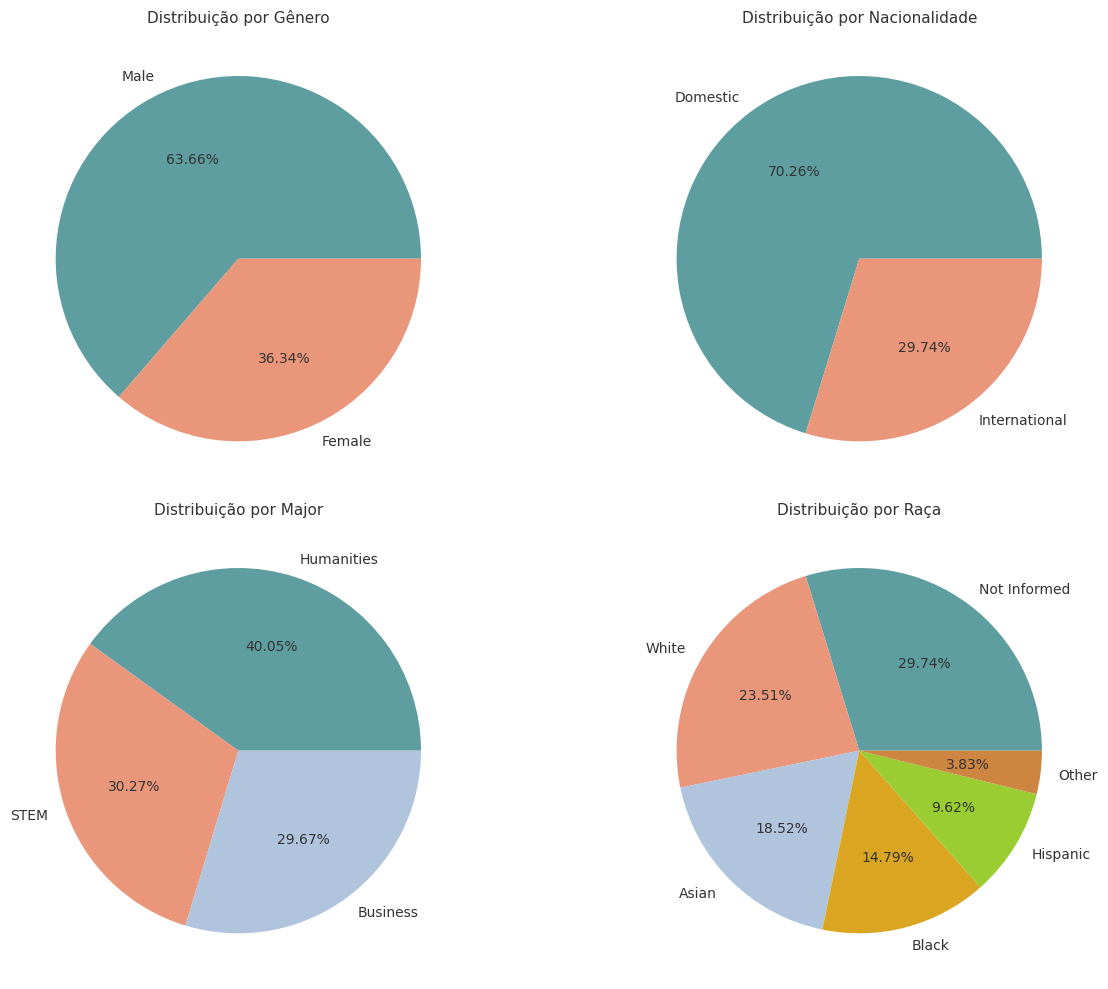

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Agora você usa SUA função personalizada em vez do plot do pandas
pizza_personalizada(df['gender'].value_counts(), ax[0,0], 'Distribuição por Gênero')
pizza_personalizada(df['international'].value_counts(), ax[0,1], 'Distribuição por Nacionalidade')
pizza_personalizada(df['major'].value_counts(), ax[1,0], 'Distribuição por Major')
pizza_personalizada(df['race'].value_counts(), ax[1,1], 'Distribuição por Raça')

plt.tight_layout()

## Questao 2

In [10]:
df['admited'] = np.where(df['admission'] == 'Admit', 1, 0)
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission,admited
0,1,Female,Domestic,3.30,Business,Asian,620.0,3.0,Financial Services,Admit,1
1,2,Male,Domestic,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN,0
2,3,Female,International,3.30,Business,Not Informed,710.0,5.0,Technology,Admit,1
3,4,Male,Domestic,3.47,STEM,Black,690.0,6.0,Technology,NaN,0
4,5,Male,Domestic,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN,0


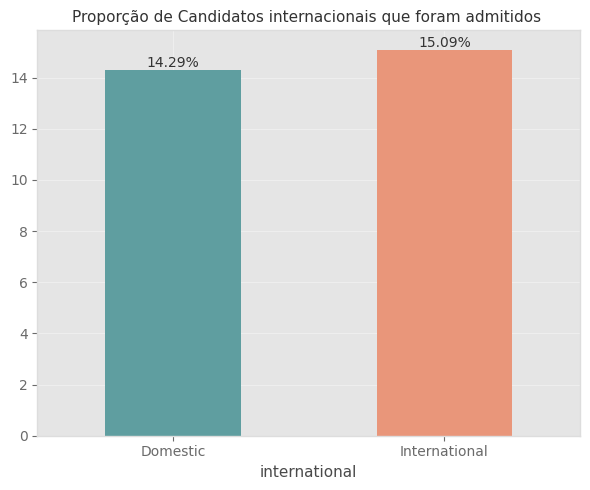

In [11]:
proporcoes_int = df.groupby('international')['admited'].mean() * 100

fig, ax = plt.subplots(figsize = (6, 5))

ax = proporcoes_int.plot(
    kind = 'bar',
    color = paleta_cores,
    ax = ax
)
for container in ax.containers:
    ax.bar_label(container, fmt = '%1.2f%%')
plt.xticks(rotation=0)
ax.set_title('Proporção de Candidatos internacionais que foram admitidos ')
plt.tight_layout()

# Questao 3

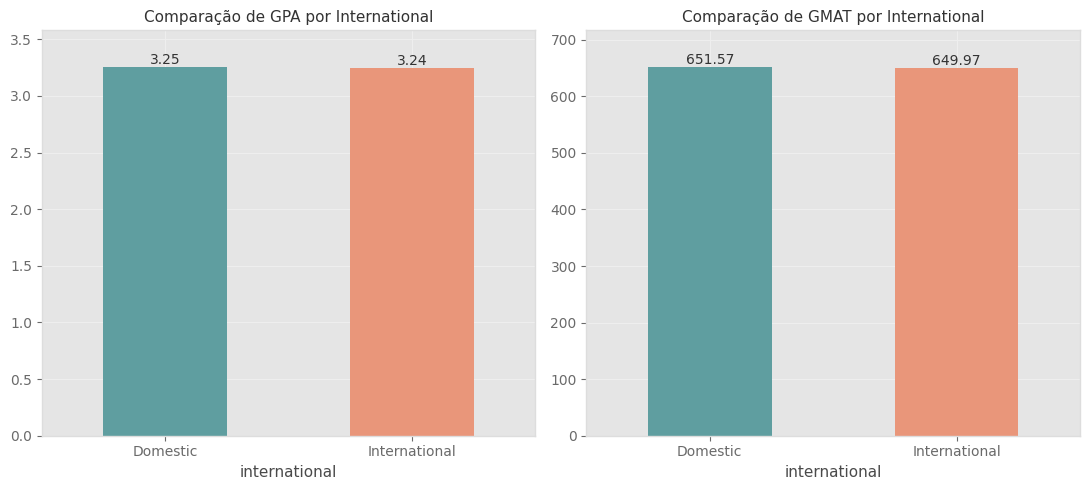

In [12]:
proporcoes_gpa = df.groupby('international')['gpa'].mean() 
proporcoes_gmat = df.groupby('international')['gmat'].mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0] = proporcoes_gpa.plot(kind = 'bar', 
                         color = paleta_cores, 
                         ax = ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f') 
ax[0].set_title('Comparação de GPA por International')    
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].set_ylim(top = proporcoes_gpa.max() * 1.1)

ax[1] = proporcoes_gmat.plot(kind = 'bar',
                             color = paleta_cores,
                             ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, fmt = '%.2f')
ax[1].set_title('Comparação de GMAT por International')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].set_ylim(top = proporcoes_gmat.max() * 1.1)
plt.tight_layout()

# Questao 4

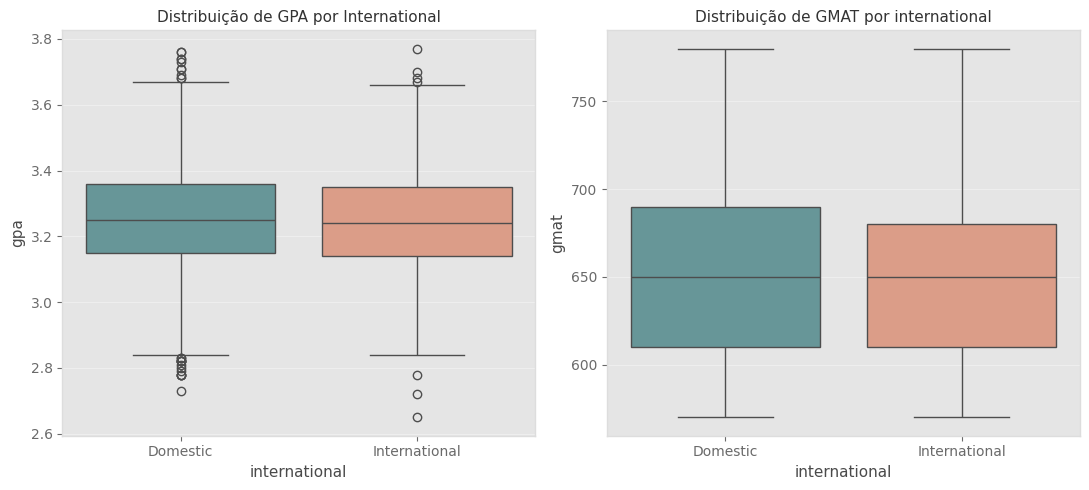

In [13]:
fig, ax = plt.subplots(1,2, figsize = (11, 5))

ax[0] = sns.boxplot(
    data = df,
    x = 'international',
    y = 'gpa',
    ax = ax[0],
    palette = paleta_cores[:2],
    hue = 'international',
    legend = False
)
ax[0].set_title('Distribuição de GPA por International')

ax[1] = sns.boxplot(
    data = df,
    x = 'international',
    y = 'gmat',
    ax = ax[1],
    palette = paleta_cores[:2],
    hue = 'international',
    legend = False
)
ax[1].set_title('Distribuição de GMAT por international')
plt.tight_layout()


# Questao 5

In [14]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission,admited
0,1,Female,Domestic,3.30,Business,Asian,620.0,3.0,Financial Services,Admit,1
1,2,Male,Domestic,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN,0
2,3,Female,International,3.30,Business,Not Informed,710.0,5.0,Technology,Admit,1
3,4,Male,Domestic,3.47,STEM,Black,690.0,6.0,Technology,NaN,0
4,5,Male,Domestic,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN,0


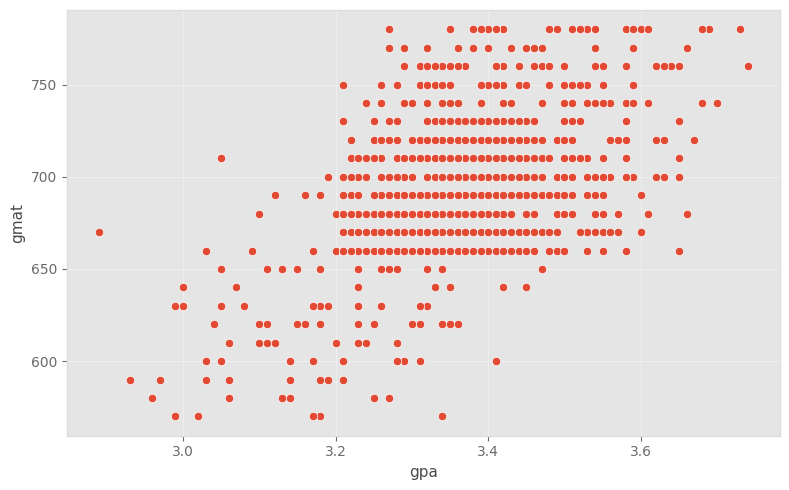

In [15]:
aprovados = df[df['admission'] == 'Admit']

fig, ax = plt.subplots(figsize = (8, 5))

ax = sns.scatterplot(
    data = aprovados,
    x = 'gpa',
    y = 'gmat'
)
plt.tight_layout()

# Questao 6

In [17]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission,admited
0,1,Female,Domestic,3.30,Business,Asian,620.0,3.0,Financial Services,Admit,1
1,2,Male,Domestic,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN,0
2,3,Female,International,3.30,Business,Not Informed,710.0,5.0,Technology,Admit,1
3,4,Male,Domestic,3.47,STEM,Black,690.0,6.0,Technology,NaN,0
4,5,Male,Domestic,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN,0


[Text(0, 0, 'Business'), Text(1, 0, 'Humanities'), Text(2, 0, 'STEM')]

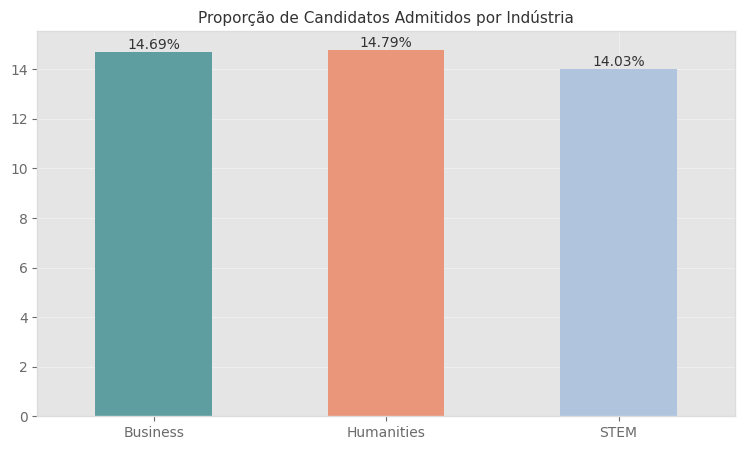

In [35]:
proporcao_adm_industria = df.groupby('major')['admited'].mean() * 100
fig,  ax  = plt.subplots(figsize = (9, 5))

ax = proporcao_adm_industria.plot(
    kind = 'bar',
    color = paleta_cores
)
for container in ax.containers:
    ax.bar_label(container, fmt = '%1.2f%%')

ax.set_title('Proporção de Candidatos Admitidos por Indústria')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 0)

#  Questao 7

In [63]:
correlacao = df['work_exp'].corr(df['admited'], method= 'pearson') * 100
print(f"Correlação de Pearson entre experiência de trabalho e admissão: {correlacao_valor:.2f}%")

Correlação de Pearson entre experiência de trabalho e admissão: 1.19%


# Questao 8

In [79]:
tabela = pd.crosstab(df['race'], df['admited'], normalize='index') * 100

# Agora aplica as renomeações no MESMO estilo que funcionou antes
tabela = (tabela                                    # ← Abre parêntese para quebrar linhas
          .rename(columns={0: 'Não ser Admitido', 1: ' Ser Admitido'})
          .rename_axis(columns='Admissão')
          .rename_axis(index='Raça'))               # ← Fecha parêntese

tabela.style.format('{:.2f}%')

Admissão,Não ser Admitido,Ser Admitido
Raça,,
Asian,83.44%,16.56%
Black,91.27%,8.73%
Hispanic,89.60%,10.40%
Not Informed,84.91%,15.09%
Other,80.59%,19.41%
White,83.24%,16.76%


# Questao 9

In [87]:
tabela_gender = df.groupby('gender')[['gpa', 'gmat']].mean().round(2)
tabela_gender = (tabela_gender
                 .rename(columns = {'gpa': 'Nota Média - GPA', 'gmat': 'Nota Média - GMAT'})
                 .rename_axis(index = 'Gênero')
                 )
tabela_gender

,Nota Média - GPA,Nota Média - GMAT
Gênero,,
Female,3.25,649.60
Male,3.25,651.94
